In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ** Task 1. Data Loading and Inspection**

In [51]:
heart_disease_csv = pd.read_csv("/content/drive/MyDrive/q1_heart_disease.csv")
heart_disease_csv.shape

(800, 12)

In [52]:
heart_disease_csv.dtypes

,0
age,int64
sex,int64
chest_pain_type,object
resting_bp,float64
cholesterol,float64
fasting_bs,int64
resting_ecg,object
max_hr,int64
exercise_angina,int64
oldpeak,float64


In [53]:
heart_disease_csv.isnull().sum()

,0
age,0
sex,0
chest_pain_type,0
resting_bp,24
cholesterol,32
fasting_bs,0
resting_ecg,0
max_hr,0
exercise_angina,0
oldpeak,0


In [54]:
heart_disease_csv.head()

,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


# **Task 2. Exploratory Data Analysis**

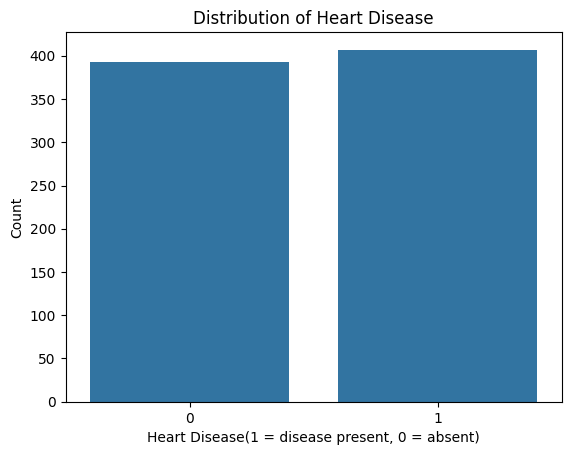

In [55]:
sns.countplot(x = 'heart_disease', data = heart_disease_csv)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease(1 = disease present, 0 = absent)')
plt.ylabel('Count')
plt.show()

# **Markdown**
The dataset is almost balanced between heart disease (1) and no disease (0).
This is good for modeling as it reduces bias toward any one class.

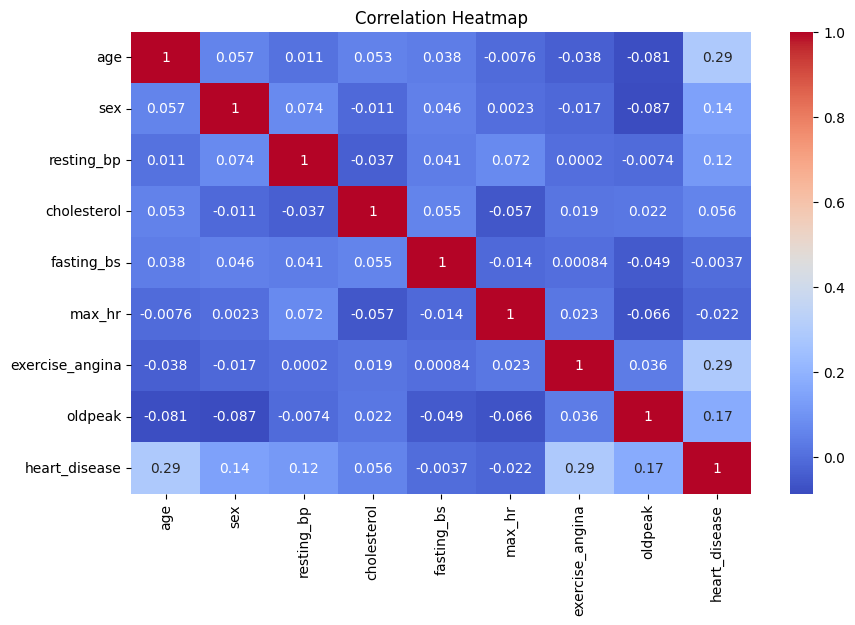

In [56]:

plt.figure(figsize=(10,6))
sns.heatmap(heart_disease_csv.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

# **Markdown**
Age and exercise_angina show the strongest positive relation with heart disease.
Most other features have weak correlation, so multiple features are needed for prediction.

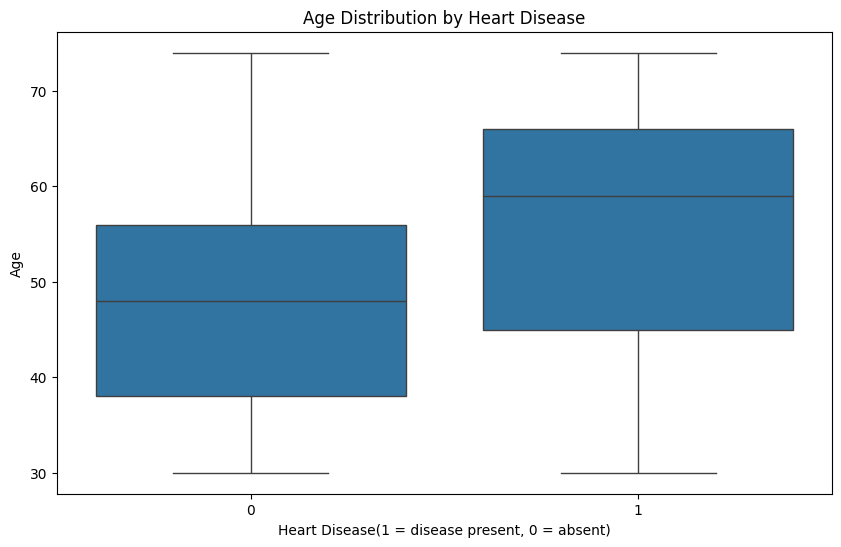

In [57]:
plt.figure(figsize=(10,6))
sns.boxplot(x='heart_disease', y='age', data=heart_disease_csv)

plt.title('Age Distribution by Heart Disease')
plt.xlabel('Heart Disease(1 = disease present, 0 = absent)')
plt.ylabel('Age')

plt.show()


# **Markdown**
Patients with heart disease tend to be older on average.
Age appears to be an important factor in predicting heart disease.

# **Task 3. Data Processing**

In [58]:
heart_disease_csv = heart_disease_csv.fillna(heart_disease_csv.median(numeric_only=True))

In [59]:
heart_disease_numeric = pd.get_dummies(heart_disease_csv, drop_first=True)

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Define X (features) and y (target variable)
X = heart_disease_numeric.drop('heart_disease', axis=1)
y = heart_disease_numeric['heart_disease']

# Perform train-test split to create X_train, X_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    stratify=y,
    random_state=42
)

scaler = StandardScaler()

nums_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

X_train[nums_cols] = scaler.fit_transform(X_train[nums_cols])
X_test[nums_cols] = scaler.transform(X_test[nums_cols])

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
    stratify=y,
    random_state=42
)

# **Task 4. Model Training**

In [62]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
print(dt_model)

DecisionTreeClassifier(random_state=42)


In [63]:
from sklearn.ensemble import RandomForestClassifier
rf_model= RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
print(rf_model)

RandomForestClassifier(random_state=42)


In [64]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
print(gb_model)

GradientBoostingClassifier(random_state=42)


# **Task 5. Model Evaluation**

In [65]:
from sklearn.metrics import confusion_matrix, classification_report

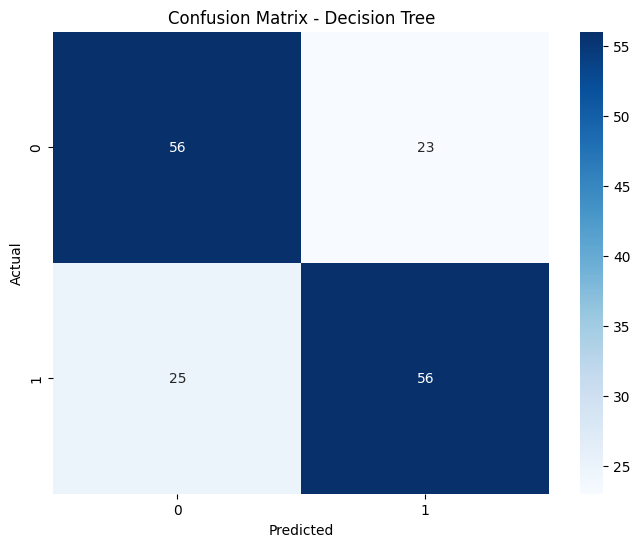

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.71      0.70        79
           1       0.71      0.69      0.70        81

    accuracy                           0.70       160
   macro avg       0.70      0.70      0.70       160
weighted avg       0.70      0.70      0.70       160



In [66]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

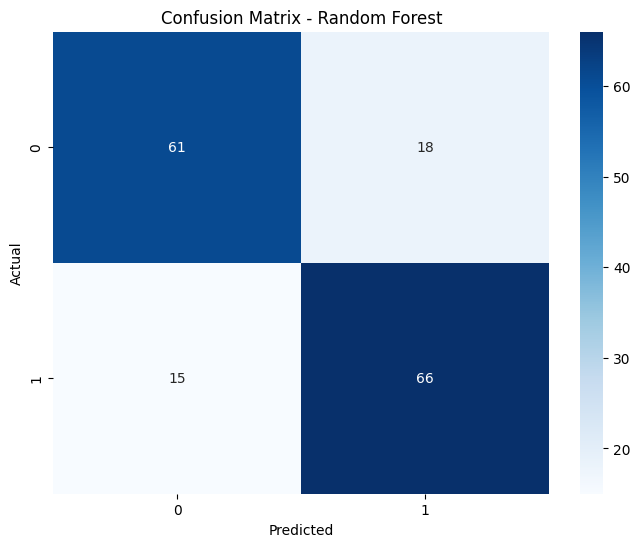

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



In [67]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

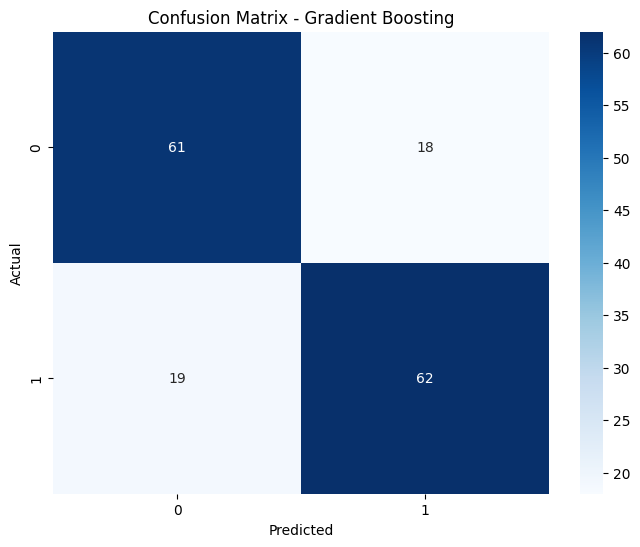

Gradient Boosting Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.77      0.77        79
           1       0.78      0.77      0.77        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



In [68]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb))


# **Markdown**
All three models were evaluated by confusion matrix, precision, recall and f-1 score.
Confusion matrix is to check number of correct and incorrect prediction made by each model.
Precision measures how many predicted positive cases were actually correct, while recall indicates how well model identifies actually positive cases. F1 scores is balance between precision and recall.
Among the model, the best performing model is the one with highest F1 score and balanced precision and recall. In medical datasets, recall is especially important because failing to detect a disease can be critical. **Overall Random Forest model provides best recall and precision with highest F1 score making it best suitable model.**


# **Task 6. Hyperparameter Tuning**

In [69]:
from sklearn.model_selection import GridSearchCV

In [70]:
param_grid = {'n_estimators':[50, 100, 200], 'max_depth':[None, 5, 10], 'min_samples_split':[2,5]}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='f1', n_jobs=-1)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='f1')

In [71]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}


In [72]:
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report
print("Tuned Random Forest:")
print(classification_report(y_test, y_pred_best_rf))

Tuned Random Forest:
              precision    recall  f1-score   support

           0       0.81      0.73      0.77        79
           1       0.76      0.83      0.79        81

    accuracy                           0.78       160
   macro avg       0.78      0.78      0.78       160
weighted avg       0.78      0.78      0.78       160

